# 🍽️ PC1 – Sistema de Recomendación de Restaurantes en Lima
### Curso: Ciencia de Datos I | Práctica Calificada 1
---
**Grupo:**
- Anchante , Marcello
- Barrientos, David
- Rios, Sebastián

## 0. Instalación de dependencias

In [27]:
#!pip install "numpy<2" -q
#!pip install scikit-surprise -q
#!pip install pandas
#!pip install seaborn
#!pip install streamlit
#!pip install streamlit_folium
#!pip install kagglehub

## 1. Selección y Exploración de Datos
### 1.1 Fuente y descripción del dataset
El dataset proviene de reseñas reales de **Google Maps** para restaurantes de Lima, Perú,
obtenidos de la plataforma Kaggle https://www.kaggle.com/datasets/bandrehc/lima-restaurant-review. Estos datos están actualizados al mes de Agosto del 2025.
Consta de dos archivos:

| Archivo | Descripción |
|---|---|
| `Lima_Restaurants_2025_08_13.csv` | 378 969 reseñas con `username`, `id_place`, `rating` (1-5) |
| `restaurant_metadata.csv` | Metadatos de 1 055 locales: nombre, categoría, distrito, coordenadas |

**Variables clave:**
- `username` → identificador del usuario (columna *usuario*)
- `id_place`  → identificador del restaurante (columna *ítem*)
- `rating`    → valoración del 1 al 5 (columna *rating*)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, KNNBasic, SVD, accuracy
from surprise.model_selection import train_test_split, cross_validate
import pickle
import kagglehub
import os

# ── Carga de datos ──────────────────────────────────────────────────────────

path = kagglehub.dataset_download("bandrehc/lima-restaurant-review")
print("Path to dataset files:", path)

file_path1=os.path.join(path,"Lima_Restaurants_2025_08_13.csv")
file_path2=os.path.join(path,"restaurant_metadata.csv")

# ── Carga de datos ──────────────────────────────────────────────────────────
reviews  = pd.read_csv(file_path1)
metadata = pd.read_csv(file_path2)

print("Reviews shape :", reviews.shape)
print("Metadata shape:", metadata.shape)
reviews.head()

D:\MARCELLO\24-2\CD2\PythonProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 27.7M/27.7M [00:02<00:00, 11.6MB/s]

Extracting files...


Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\bandrehc\lima-restaurant-review\versions\2
Reviews shape : (378969, 11)
Metadata shape: (1055, 14)


,id_review,caption,relative_date,review_date,retrieval_date,rating,username,n_review_user,url_user,url_place,id_place
0,ChZDSUhNMG9nS0VJQ0FnSUNVLV9HNEJ3EAE,NaN,Hace 6 años,2019-08-14 02:55:32.748162,2025-08-12 02:55:32.748162,5,Eduardo Rentería,0,https://www.google.com/maps/contrib/1146375908...,https://www.google.com/maps/place/?q=place_id:...,ChIJ--Rcshq4BZERPIDegz6p5-o
1,ChZDSUhNMG9nS0VJQ0FnSURrb2FUZk5REAE,NaN,Hace 6 años,2019-08-14 02:55:32.748573,2025-08-12 02:55:32.748573,5,Margot Menacho,0,https://www.google.com/maps/contrib/1152404922...,https://www.google.com/maps/place/?q=place_id:...,ChIJ--Rcshq4BZERPIDegz6p5-o
2,ChdDSUhNMG9nS0VJQ0FnSUNFdEtlbW93RRAB,NaN,Hace 6 años,2019-08-14 02:55:32.749164,2025-08-12 02:55:32.749164,5,Johrdan Davila Ruiz,2,https://www.google.com/maps/contrib/1146353983...,https://www.google.com/maps/place/?q=place_id:...,ChIJ--Rcshq4BZERPIDegz6p5-o
3,ChdDSUhNMG9nS0VJQ0FnSUNFNE5PYV9BRRAB,"Sirven menú variado de lunes a viernes, en bas...",Hace 6 años,2019-08-14 02:55:32.749667,2025-08-12 02:55:32.749667,3,Luis Anticona,31,https://www.google.com/maps/contrib/1029463912...,https://www.google.com/maps/place/?q=place_id:...,ChIJ--Rcshq4BZERPIDegz6p5-o
4,ChZDSUhNMG9nS0VJQ0FnSURZNzV6akRREAE,Todo muy rico peeo caro,Hace 6 años,2019-08-14 02:55:32.750200,2025-08-12 02:55:32.750200,4,Adrian Rebaza,67,https://www.google.com/maps/contrib/1063973783...,https://www.google.com/maps/place/?q=place_id:...,ChIJ--Rcshq4BZERPIDegz6p5-o


In [31]:
# Estructura del dataset de reseñas
print(reviews.dtypes)

id_review           str
caption             str
relative_date       str
review_date         str
retrieval_date      str
rating            int64
username            str
n_review_user     int64
url_user            str
url_place           str
id_place            str
dtype: object


In [32]:
# Vista de metadatos
metadata.head()

,id_place,url_place,title,category,address,phoneNumber,completePhoneNumber,domain,url,stars,reviews,district,lat,long
0,ChIJ41RbR-W3BZERtC40lE27kJI,https://www.google.com/maps/place/?q=place_id:...,La 73,Restaurante,"Av. el Sol 175, Barranco 15063",(01) 2470780,+51 1 2470780,instagram.com,https://instagram.com/la73_barranco?utm_medium...,4.4,1741.0,Barranco,-12.139661,-77.023216
1,ChIJq6DzbfK3BZERzmnElUR7PUM,https://www.google.com/maps/place/?q=place_id:...,Pan Sal Aire,Restaurante,"Av. Almte. Miguel Grau 320, , Lima, Barranco 1...",951 118 993,+51 951 118 993,delivery.pansalaire.pe,https://delivery.pansalaire.pe/,4.6,2229.0,Barranco,-12.148280,-77.021087
2,ChIJQwRnc-23BZERpyhQvLJVMTQ,https://www.google.com/maps/place/?q=place_id:...,Restaurante Javier,Restaurante peruano,"Bajada de Baños 408, Barranco 15063",984 799 808,+51 984 799 808,www.restaurantejavier.pe,https://www.restaurantejavier.pe/,4.3,6810.0,Barranco,-12.149831,-77.023228
3,ChIJbYWvNb63BZER3Mb9WXTrobo,https://www.google.com/maps/place/?q=place_id:...,Nuestro Bistro,Restaurante,"Jr. Colina 107, Barranco 15063",948 721 346,+51 948 721 346,www.instagram.com,https://www.instagram.com/nuestro_bistro/,4.9,122.0,Barranco,-12.145981,-77.022046
4,ChIJQWG-5e63BZERioL90gT0vZ8,https://www.google.com/maps/place/?q=place_id:...,Cala Restaurante & Lounge,Restaurante,"Circuito de Playas, Barranco 15063",998 247 326,+51 998 247 326,NaN,NaN,4.4,8900.0,Barranco,-12.144648,-77.025753


In [5]:
# Estadísticas generales
print(f"Usuarios únicos    : {reviews['username'].nunique():,}")
print(f"Restaurantes únicos: {reviews['id_place'].nunique():,}")
print(f"Total de reseñas   : {len(reviews):,}\n")
print("Distribución de ratings:")
print(reviews['rating'].value_counts().sort_index())

Usuarios únicos    : 216,336
Restaurantes únicos: 1,012
Total de reseñas   : 378,969

Distribución de ratings:
rating
1     18134
2     11287
3     34064
4     86603
5    228881
Name: count, dtype: int64


## 2. Preprocesamiento y Análisis Exploratorio
### 2.1 Limpieza y filtrado
Aplicamos **filtrado por densidad**: conservamos solo usuarios con ≥ 10 reseñas
y restaurantes con ≥ 20 reseñas para garantizar señal estadística suficiente.

In [6]:
# ── Unir metadatos ──────────────────────────────────────────────────────────
df = reviews.merge(
    metadata[['id_place','title','category','district']],
    on='id_place', how='left'
)

# ── Filtrado por densidad ────────────────────────────────────────────────────
user_counts  = df['username'].value_counts()
place_counts = df['id_place'].value_counts()

df = df[
    df['username'].isin(user_counts[user_counts >= 10].index) &
    df['id_place'].isin(place_counts[place_counts >= 20].index)
]

# Eliminar duplicados usuario-restaurante (nos quedamos con la última reseña)
df = df.drop_duplicates(subset=['username','id_place'])
df = df.reset_index(drop=True)

print(f"Reseñas tras filtrado  : {len(df):,}")
print(f"Usuarios únicos        : {df['username'].nunique():,}")
print(f"Restaurantes únicos    : {df['id_place'].nunique():,}")
print(f"Sparsity (% vacíos)    : {1 - len(df)/(df['username'].nunique()*df['id_place'].nunique()):.2%}")

Reseñas tras filtrado  : 41,294
Usuarios únicos        : 2,831
Restaurantes únicos    : 823
Sparsity (% vacíos)    : 98.23%


### 2.2 Visualizaciones

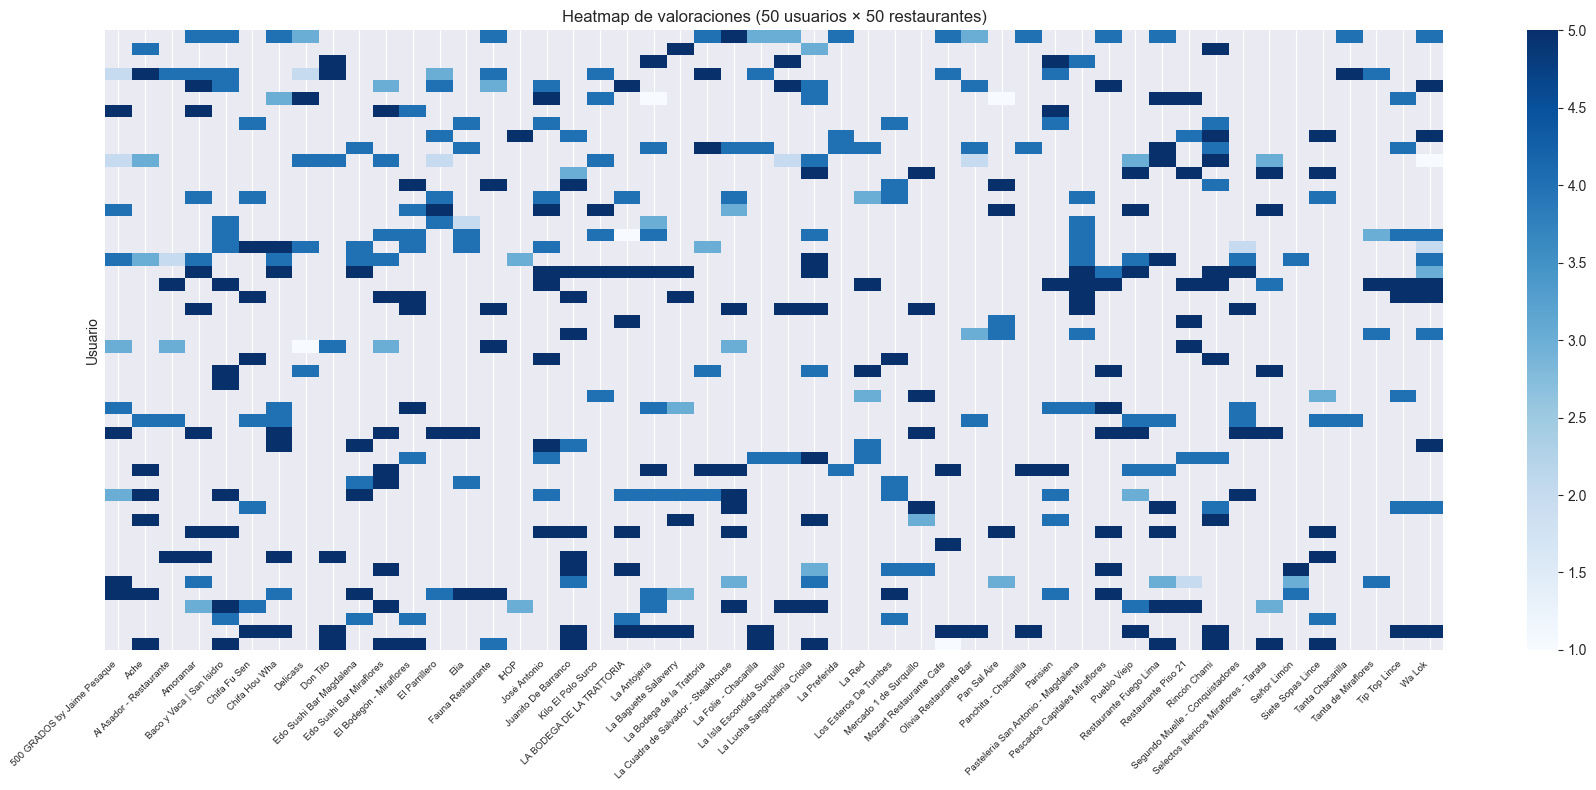

In [7]:
# ── Heatmap (muestra 50 usuarios x 50 restaurantes) ─────────────────────────
top50_users  = df['username'].value_counts().head(50).index
top50_places = df['id_place'].value_counts().head(50).index

sub = df[df['username'].isin(top50_users) & df['id_place'].isin(top50_places)].copy()

# Reemplazar id_place por el nombre del restaurante
id_to_title = metadata.set_index('id_place')['title'].to_dict()
sub['restaurante'] = sub['id_place'].map(id_to_title)

matrix_sub = sub.pivot(index='username', columns='restaurante', values='rating')

plt.figure(figsize=(18, 8))
sns.heatmap(matrix_sub, cmap='Blues', cbar=True,
            xticklabels=True, yticklabels=False)
plt.title("Heatmap de valoraciones (50 usuarios × 50 restaurantes)")
plt.xlabel("")
plt.ylabel("Usuario")
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

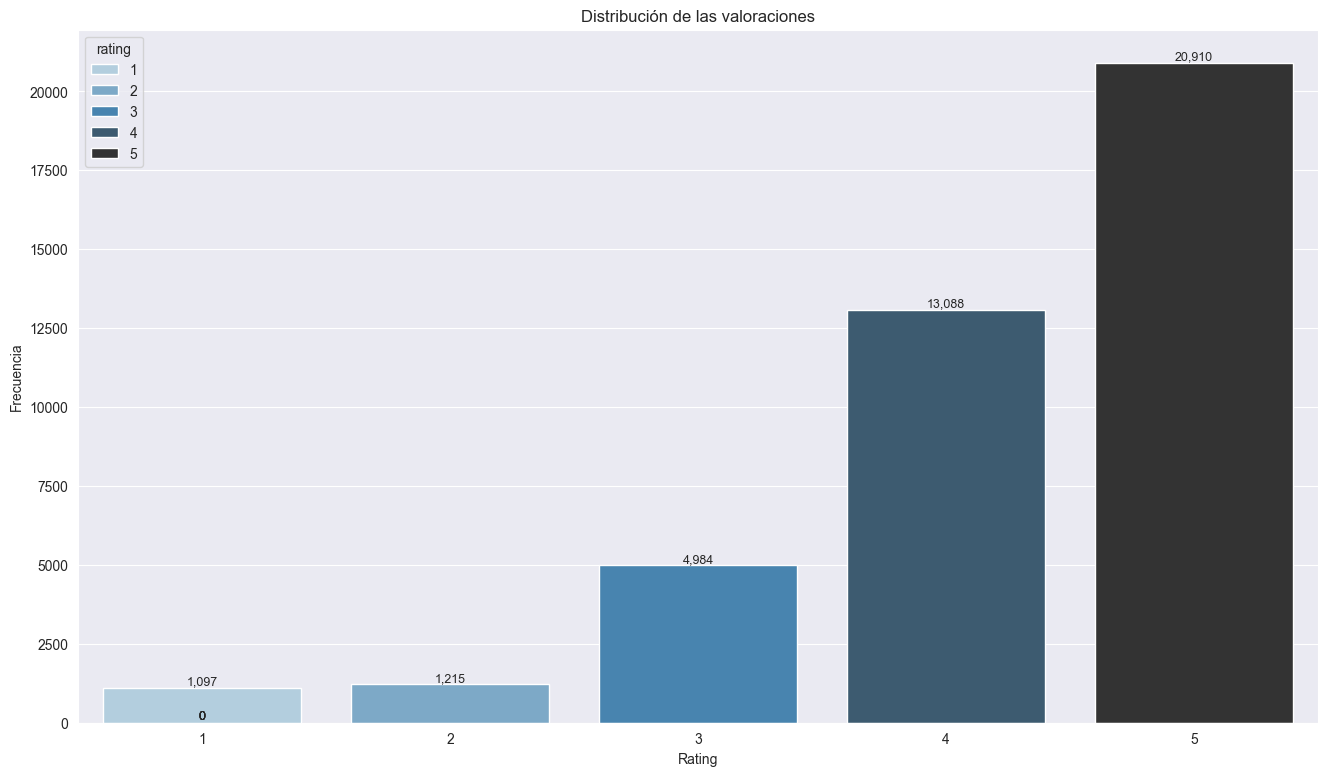

Resumen estadístico:
count    41294.000000
mean         4.247130
std          0.960623
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64


In [8]:
# ── Distribución de ratings ─────────────────────────────────────────────────
plt.figure(figsize=(16,9))
sns.countplot(x='rating', data=df, hue = 'rating', palette='Blues_d')
plt.title("Distribución de las valoraciones")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height()):,}",
                       (p.get_x()+p.get_width()/2, p.get_height()+100),
                       ha='center', fontsize=9)
plt.show()

print("Resumen estadístico:")
print(df['rating'].describe())

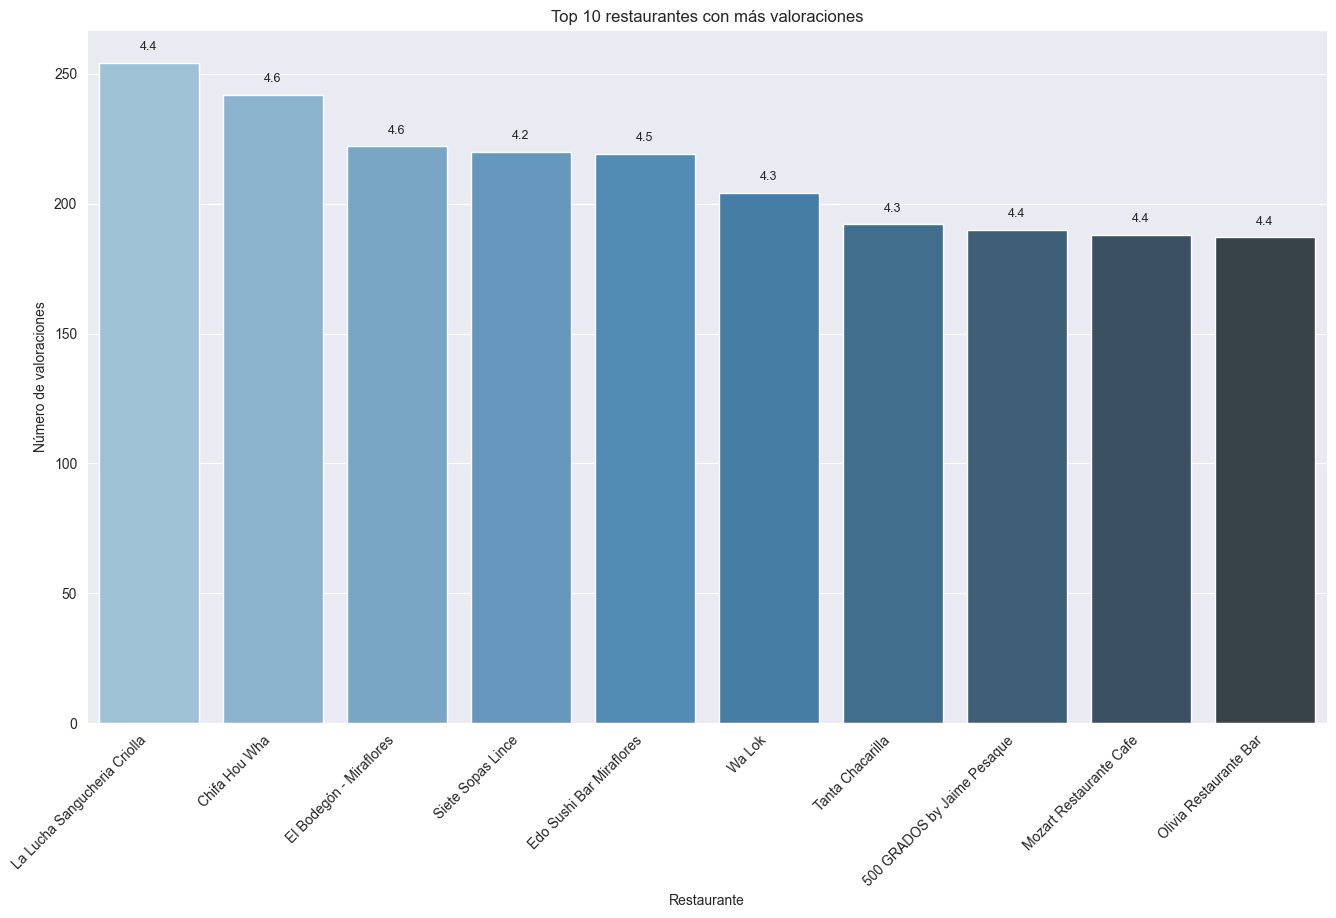

In [9]:
# ── Top 10 restaurantes más valorados ───────────────────────────────────────
# Agrupamos por id_place (existe en df) y luego traemos el título desde metadata
top_places = (df.groupby('id_place')['rating']
               .agg(['count','mean'])
               .reset_index())
top_places = top_places.merge(metadata[['id_place','title']], on='id_place', how='left')
top_places = (top_places.sort_values('count', ascending=False)
               .head(10)
               .reset_index(drop=True))
top_places.columns = ['id_place','N_valoraciones','Rating_promedio','Restaurante']

plt.figure(figsize=(16,9))
sns.barplot(data=top_places, x='Restaurante', y='N_valoraciones', hue = 'Restaurante', palette='Blues_d')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 restaurantes con más valoraciones")
plt.ylabel("Número de valoraciones")
for i, row in top_places.iterrows():
    plt.text(i, row['N_valoraciones']+5, f"{row['Rating_promedio']:.1f}",
             ha='center', fontsize=9)

plt.show()

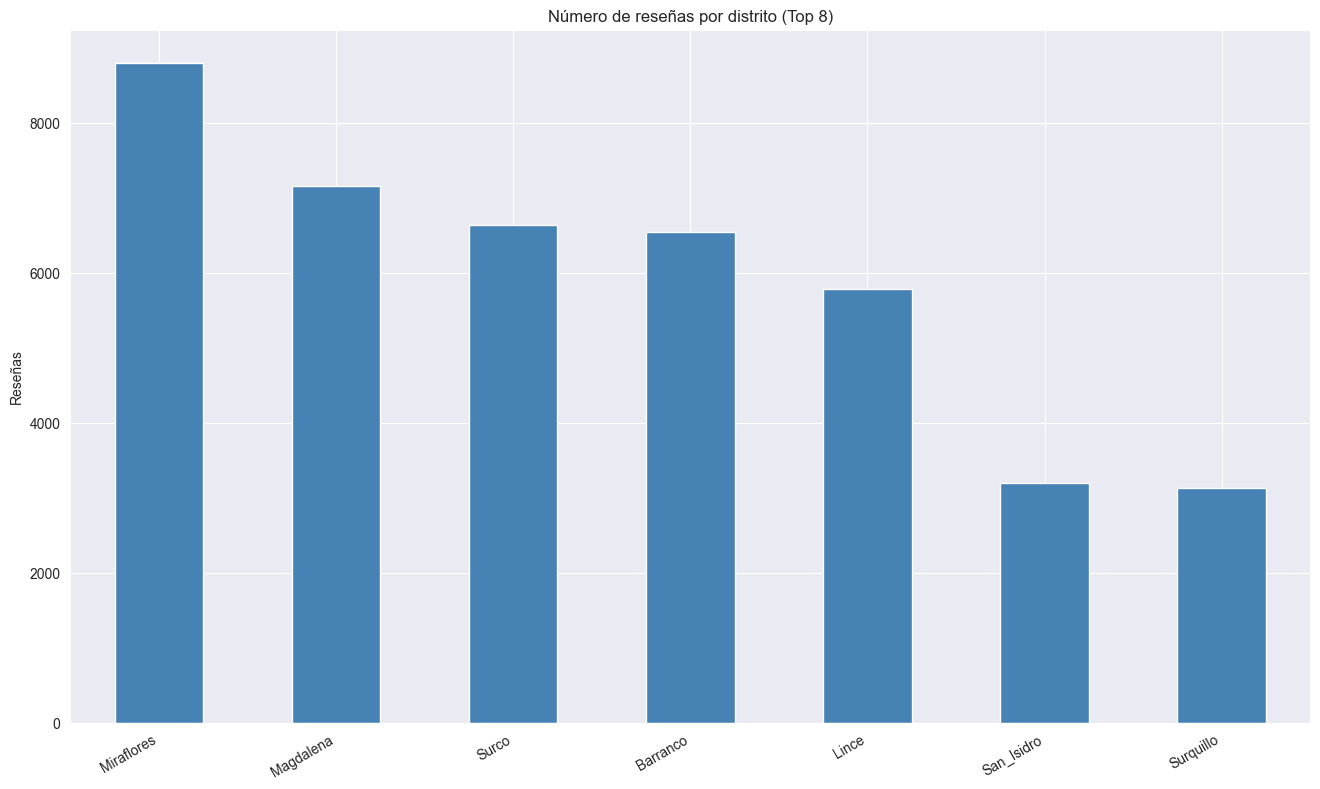

In [10]:
# ── Reseñas por distrito ────────────────────────────────────────────────────
dist = (df.merge(metadata[['id_place','district']], on='id_place', how='left')
          ['district_x'].value_counts().head(8))

plt.figure(figsize=(16,9))
dist.plot(kind='bar', color='steelblue')
plt.title("Número de reseñas por distrito (Top 8)")
plt.xlabel("")
plt.ylabel("Reseñas")
plt.xticks(rotation=30, ha='right')
plt.show()

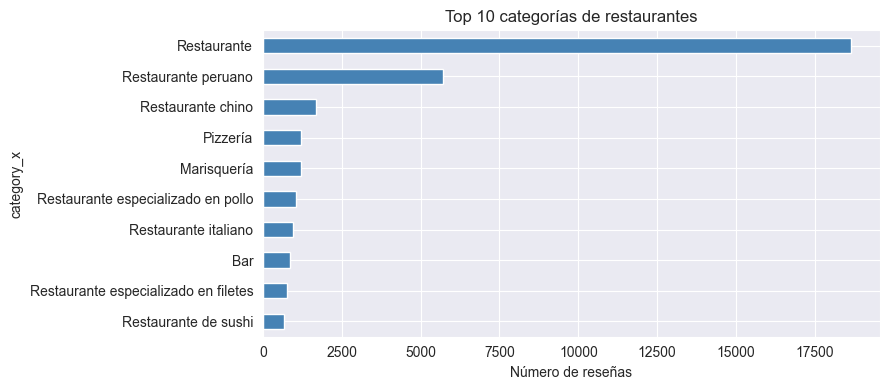

In [11]:
# ── Categorías de restaurantes ──────────────────────────────────────────────
cats = df.merge(metadata[['id_place','category']], on='id_place', how='left')['category_x'].value_counts().head(10)

plt.figure(figsize=(9,4))
cats.plot(kind='barh', color='steelblue')
plt.title("Top 10 categorías de restaurantes")
plt.xlabel("Número de reseñas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

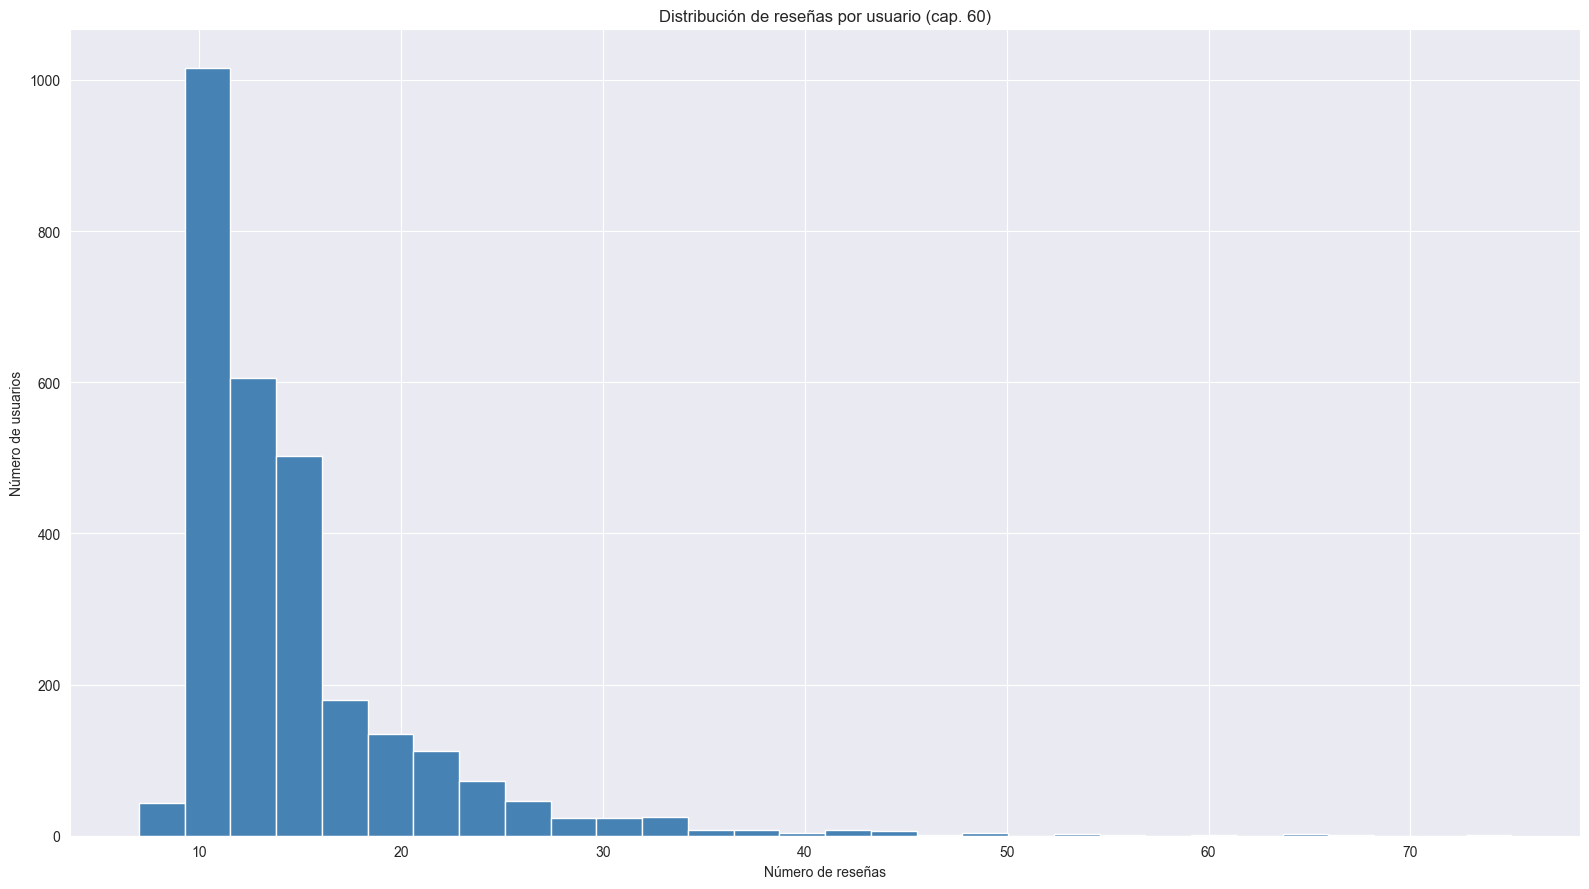

In [12]:
# ── Reseñas por usuario (distribución) ──────────────────────────────────────
plt.figure(figsize=(16,9))
df['username'].value_counts().hist(bins=30, color='steelblue', edgecolor='white')
plt.title("Distribución de reseñas por usuario (cap. 60)")
plt.xlabel("Número de reseñas")
plt.ylabel("Número de usuarios")
plt.tight_layout()
plt.show()

In [13]:
df['username'].value_counts().describe()

count    2831.000000
mean       14.586365
std         6.206307
min         7.000000
25%        11.000000
50%        13.000000
75%        16.000000
max        75.000000
Name: count, dtype: float64

## 3. Implementación de Modelos de Recomendación
Se implementan tres modelos usando **scikit-surprise**:

| Modelo | Tipo | Descripción |
|---|---|---|
| **UBCF** | Filtrado colaborativo basado en usuario | Recomienda ítems que gustaron a usuarios similares |
| **IBCF** | Filtrado colaborativo basado en ítem | Recomienda restaurantes similares a los ya valorados |
|**Híbrido**| Pesos para UBCF y IBCF | Recopila ambas técnicas utilizadas y las pondera |

### 3.1 Preparación del dataset para Surprise

In [14]:
# ── Dataset en formato Surprise ─────────────────────────────────────────────
reader   = Reader(rating_scale=(1, 5))
data_sur = Dataset.load_from_df(df[['username', 'id_place', 'rating']], reader)

# División train/test (80/20)
trainset, testset = train_test_split(data_sur, test_size=0.2, random_state=42)
print(f"Entrenamiento: {trainset.n_ratings:,} ratings")
print(f"Prueba        : {len(testset):,} ratings")

Entrenamiento: 33,035 ratings
Prueba        : 8,259 ratings


### 3.2 Modelo 1 – UBCF (User-Based Collaborative Filtering)

In [15]:
# ── UBCF ────────────────────────────────────────────────────────────────────
sim_options_user = {'name': 'cosine', 'user_based': True}
ubcf_model = KNNBasic(sim_options=sim_options_user)
ubcf_model.fit(trainset)

predictions_ubcf = ubcf_model.test(testset)
rmse_ubcf = accuracy.rmse(predictions_ubcf)
mae_ubcf  = accuracy.mae(predictions_ubcf)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9919
MAE:  0.7674


### 3.3 Modelo 2 – IBCF (Item-Based Collaborative Filtering)

In [16]:
# ── IBCF ────────────────────────────────────────────────────────────────────
sim_options_item = {'name': 'cosine', 'user_based': False}
ibcf_model = KNNBasic(sim_options=sim_options_item)
ibcf_model.fit(trainset)

predictions_ibcf = ibcf_model.test(testset)
rmse_ibcf = accuracy.rmse(predictions_ibcf)
mae_ibcf  = accuracy.mae(predictions_ibcf)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9356
MAE:  0.6473


### 3.4 Modelo 3 - Híbrido IBCF - UBCF

In [17]:
# ── Grid Search sobre pesos ─────────────────────────────────────────────────
grid_resultados = []

for w in np.arange(0.0, 1.05, 0.1):
    w = round(w, 1)
    hybrid_preds = []
    for pred_u, pred_i in zip(predictions_ubcf, predictions_ibcf):
        est = w * pred_u.est + (1 - w) * pred_i.est
        hybrid_preds.append((pred_u.r_ui, est))

    rmse_h = np.sqrt(np.mean([(true - est)**2 for true, est in hybrid_preds]))
    mae_h  = np.mean([abs(true - est) for true, est in hybrid_preds])
    grid_resultados.append({
        'w_UBCF': w,
        'w_IBCF': round(1 - w, 1),
        'RMSE'  : round(rmse_h, 4),
        'MAE'   : round(mae_h, 4)
    })

grid_df = pd.DataFrame(grid_resultados)
print("Resultados del Grid Search:")
print(grid_df.to_string(index=False))

# Mejor combinación por RMSE
best_row  = grid_df.loc[grid_df['RMSE'].idxmin()]
best_w_ubcf = best_row['w_UBCF']
best_w_ibcf = best_row['w_IBCF']
best_rmse_h = best_row['RMSE']
best_mae_h  = best_row['MAE']

print(f"\nMejor combinación → w_UBCF={best_w_ubcf}, w_IBCF={best_w_ibcf}")
print(f"   RMSE={best_rmse_h:.4f}  MAE={best_mae_h:.4f}")

Resultados del Grid Search:
 w_UBCF  w_IBCF   RMSE    MAE
    0.0     1.0 0.9356 0.6473
    0.1     0.9 0.9214 0.6496
    0.2     0.8 0.9115 0.6533
    0.3     0.7 0.9061 0.6590
    0.4     0.6 0.9053 0.6669
    0.5     0.5 0.9090 0.6772
    0.6     0.4 0.9172 0.6903
    0.7     0.3 0.9298 0.7062
    0.8     0.2 0.9466 0.7246
    0.9     0.1 0.9674 0.7452
    1.0     0.0 0.9919 0.7674

Mejor combinación → w_UBCF=0.4, w_IBCF=0.6
   RMSE=0.9053  MAE=0.6669


In [18]:
# ── Predicciones finales con los pesos óptimos ──────────────────────────────
hybrid_final = []
for pred_u, pred_i in zip(predictions_ubcf, predictions_ibcf):
    est = best_w_ubcf * pred_u.est + best_w_ibcf * pred_i.est
    # Construimos un objeto similar a las predicciones de Surprise
    hybrid_final.append({
        'uid'       : pred_u.uid,
        'iid'       : pred_u.iid,
        'r_ui'      : pred_u.r_ui,
        'est_hybrid': est
    })

hybrid_df = pd.DataFrame(hybrid_final)
rmse_hybrid = np.sqrt(np.mean((hybrid_df['r_ui'] - hybrid_df['est_hybrid'])**2))
mae_hybrid  = np.mean(np.abs(hybrid_df['r_ui'] - hybrid_df['est_hybrid']))

print(f"Híbrido (w_UBCF={best_w_ubcf}, w_IBCF={best_w_ibcf})")
print(f"  RMSE = {rmse_hybrid:.4f}")
print(f"  MAE  = {mae_hybrid:.4f}")

Híbrido (w_UBCF=0.4, w_IBCF=0.6)
  RMSE = 0.9053
  MAE  = 0.6669


### 3.5 Comparación de métricas

In [19]:
# ── Tabla comparativa ───────────────────────────────────────────────────────
comparativa = pd.DataFrame({
    'Modelo': [
        'UBCF (coseno)',
        'IBCF (coseno)',
        f'Híbrido ({best_w_ubcf}×UBCF + {best_w_ibcf}×IBCF)'
    ],
    'RMSE': [rmse_ubcf, rmse_ibcf, rmse_hybrid],
    'MAE' : [mae_ubcf,  mae_ibcf,  mae_hybrid]
}).set_index('Modelo')

print(comparativa.round(4))

                                 RMSE     MAE
Modelo                                       
UBCF (coseno)                  0.9919  0.7674
IBCF (coseno)                  0.9356  0.6473
Híbrido (0.4×UBCF + 0.6×IBCF)  0.9053  0.6669


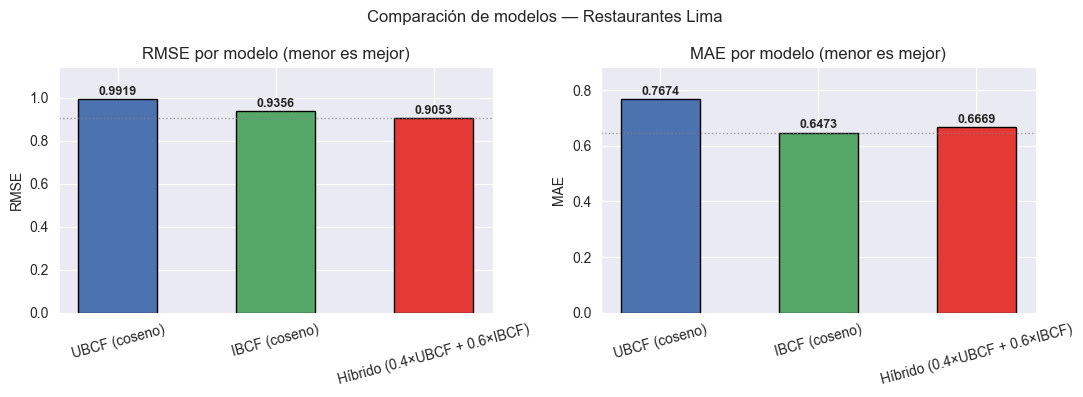

In [20]:
# ── Gráfica comparativa RMSE y MAE ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ['#4C72B0', '#55A868', '#e53935']

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.bar(comparativa.index, comparativa[metric],
                  color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{metric} por modelo (menor es mejor)')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, comparativa[metric].max() * 1.15)
    for bar, val in zip(bars, comparativa[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.005,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Línea de referencia en el mínimo
    ax.axhline(comparativa[metric].min(), color='gray',
               linestyle=':', linewidth=1, alpha=0.7)

plt.suptitle('Comparación de modelos — Restaurantes Lima', fontsize=12)
plt.tight_layout()
plt.show()

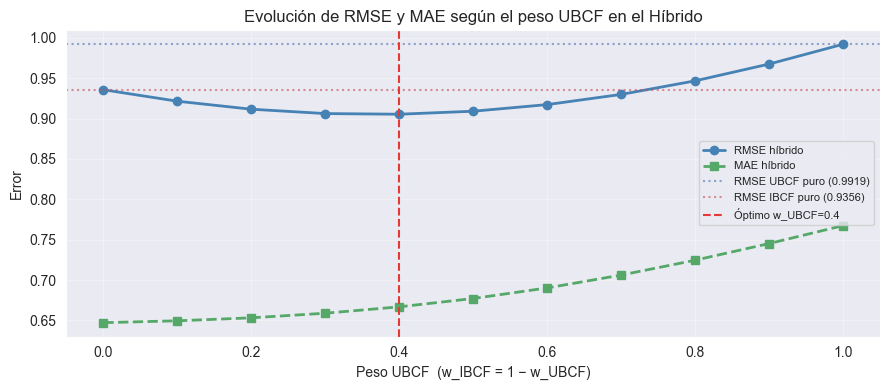

In [21]:
# ── Gráfica de línea: evolución del error en el grid search ─────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(grid_df['w_UBCF'], grid_df['RMSE'],
        marker='o', label='RMSE híbrido', color='steelblue', linewidth=2)
ax.plot(grid_df['w_UBCF'], grid_df['MAE'],
        marker='s', label='MAE híbrido',  color='#55A868',   linewidth=2, linestyle='--')

# Referencias UBCF y IBCF puros
ax.axhline(rmse_ubcf, color='#4C72B0', linestyle=':', alpha=0.6, label=f'RMSE UBCF puro ({rmse_ubcf:.4f})')
ax.axhline(rmse_ibcf, color='#C44E52', linestyle=':', alpha=0.6, label=f'RMSE IBCF puro ({rmse_ibcf:.4f})')

# Punto óptimo
ax.axvline(best_w_ubcf, color='#e53935', linestyle='--',
           linewidth=1.5, label=f'Óptimo w_UBCF={best_w_ubcf}')

ax.set_xlabel('Peso UBCF  (w_IBCF = 1 − w_UBCF)')
ax.set_ylabel('Error')
ax.set_title('Evolución de RMSE y MAE según el peso UBCF en el Híbrido')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Justificación del modelo seleccionado

**Modelo elegido: Híbrido**

### 3.7 Validación cruzada (5 folds)

In [22]:
configuraciones = [
    ("UBCF.cosine",  {'name': 'cosine',  'user_based': True}),
    ("UBCF.pearson", {'name': 'pearson', 'user_based': True}),
    ("IBCF.cosine",  {'name': 'cosine',  'user_based': False}),
    ("IBCF.pearson", {'name': 'pearson', 'user_based': False}),
]

cv_resultados = {}
for nombre, sim_options in configuraciones:
    print(f"Entrenando {nombre}...")
    modelo = KNNBasic(sim_options=sim_options)
    cv = cross_validate(modelo, data_sur, cv=5,
                        measures=['RMSE','MAE'], verbose=False)
    cv_resultados[nombre] = cv

print("\n=== Resumen cross-validation (promedio 5 folds) ===")
for nombre, cv in cv_resultados.items():
    rmse = cv['test_rmse'].mean()
    mae  = cv['test_mae'].mean()
    print(f"{nombre:20s}: RMSE={rmse:.4f}, MAE={mae:.4f}")

Entrenando UBCF.cosine...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Entrenando UBCF.pearson...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Entrenando IBCF.cosine...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Comp

In [23]:
modelo_exportar = {
    'ubcf'      : ubcf_model,
    'ibcf'      : ibcf_model,
    'w_ubcf'    : best_w_ubcf,
    'w_ibcf'    : best_w_ibcf,
    'rmse_ubcf' : rmse_ubcf,
    'rmse_ibcf' : rmse_ibcf,
    'rmse_hybrid': rmse_hybrid,
    'mae_ubcf'  : mae_ubcf,
    'mae_ibcf'  : mae_ibcf,
    'mae_hybrid': mae_hybrid,
}

with open('modelo_hibrido.pkl', 'wb') as f:
    pickle.dump(modelo_exportar, f)

print("✅ modelo_hibrido.pkl exportado correctamente")
print(f"   Pesos óptimos: w_UBCF={best_w_ubcf}, w_IBCF={best_w_ibcf}")
print(f"   RMSE híbrido : {rmse_hybrid:.4f}")
print(f"   MAE híbrido  : {mae_hybrid:.4f}")

✅ modelo_hibrido.pkl exportado correctamente
   Pesos óptimos: w_UBCF=0.4, w_IBCF=0.6
   RMSE híbrido : 0.9053
   MAE híbrido  : 0.6669


## 4. Generación de Recomendaciones
### 4.1 Función de recomendación

In [24]:
def recomendar_hibrido(ubcf, ibcf, w_ubcf, w_ibcf,
                       username, df_ratings, df_meta, top_n=10):
    """
    Genera top-N recomendaciones de restaurantes usando el modelo híbrido.

    Parámetros
    ----------
    ubcf      : modelo UBCF entrenado (KNNBasic)
    ibcf      : modelo IBCF entrenado (KNNBasic)
    w_ubcf    : peso del modelo UBCF
    w_ibcf    : peso del modelo IBCF  (w_ubcf + w_ibcf debe = 1)
    username  : nombre de usuario objetivo
    df_ratings: DataFrame con columnas [username, id_place, rating]
    df_meta   : DataFrame con metadatos de restaurantes
    top_n     : número de recomendaciones a devolver

    Retorna
    -------
    DataFrame con columnas: restaurante, categoría, distrito, rating_estimado
    """
    # Restaurantes ya valorados por el usuario
    ya_visto   = df_ratings[df_ratings['username'] == username]['id_place'].unique()
    candidatos = [p for p in df_ratings['id_place'].unique() if p not in ya_visto]

    # Predicción híbrida para cada candidato
    preds = []
    for place in candidatos:
        est_ubcf = ubcf.predict(uid=username, iid=place).est
        est_ibcf = ibcf.predict(uid=username, iid=place).est
        est_hibrido = w_ubcf * est_ubcf + w_ibcf * est_ibcf
        preds.append((place, est_hibrido, est_ubcf, est_ibcf))

    # Ordenar por rating híbrido
    preds_sorted = sorted(preds, key=lambda x: x[1], reverse=True)[:top_n]

    result = pd.DataFrame(preds_sorted,
                          columns=['id_place','rating_hibrido',
                                   'rating_ubcf','rating_ibcf'])
    result = result.merge(
        df_meta[['id_place','title','category','district']],
        on='id_place', how='left'
    )
    result = result[['title','category','district',
                     'rating_hibrido','rating_ubcf','rating_ibcf']]
    result.columns = ['Restaurante','Categoría','Distrito',
                      'Rating Híbrido','Rating UBCF','Rating IBCF']
    return result

### 4.2 Recomendaciones con sistema híbrido

In [25]:
# Usuario con más reseñas
usuario_1 = df['username'].value_counts().index[0]

print(f"=== Recomendaciones Híbrido para: {usuario_1} ===")
print(f"(Ha valorado {len(df[df['username']==usuario_1])} restaurantes)\n")

top10_u1 = recomendar_hibrido(
    ubcf_model, ibcf_model, best_w_ubcf, best_w_ibcf,
    usuario_1, df, metadata, top_n=10
)
print(top10_u1.to_string(index=False))

=== Recomendaciones Híbrido para: Carlos ===
(Ha valorado 75 restaurantes)

                 Restaurante   Categoría   Distrito  Rating Híbrido  Rating UBCF  Rating IBCF
     Restaurante Plato Hondo Restaurante      Lince        5.000000     5.000000     5.000000
               El Buen Sabor Restaurante      Surco        5.000000     5.000000     5.000000
            La Buena Familia Restaurante  Magdalena        5.000000     5.000000     5.000000
        El Gran Combo Gurmet Marisquería  Surquillo        4.880000     5.000000     4.800000
              Come con Causa Restaurante San_Isidro        4.800508     4.501269     5.000000
                     Tirreno Restaurante Miraflores        4.800000     5.000000     4.666667
 Babaganoush Restaurante-Bar Restaurante  Magdalena        4.800000     5.000000     4.666667
      DMartin - El Buen Cafe   Cafetería  Magdalena        4.760725     5.000000     4.601208
      Granja Azul San Isidro Restaurante San_Isidro        4.723229     5.0000

### 4.3 Comparación UBCF vs IBCF vs SVD para el mismo usuario

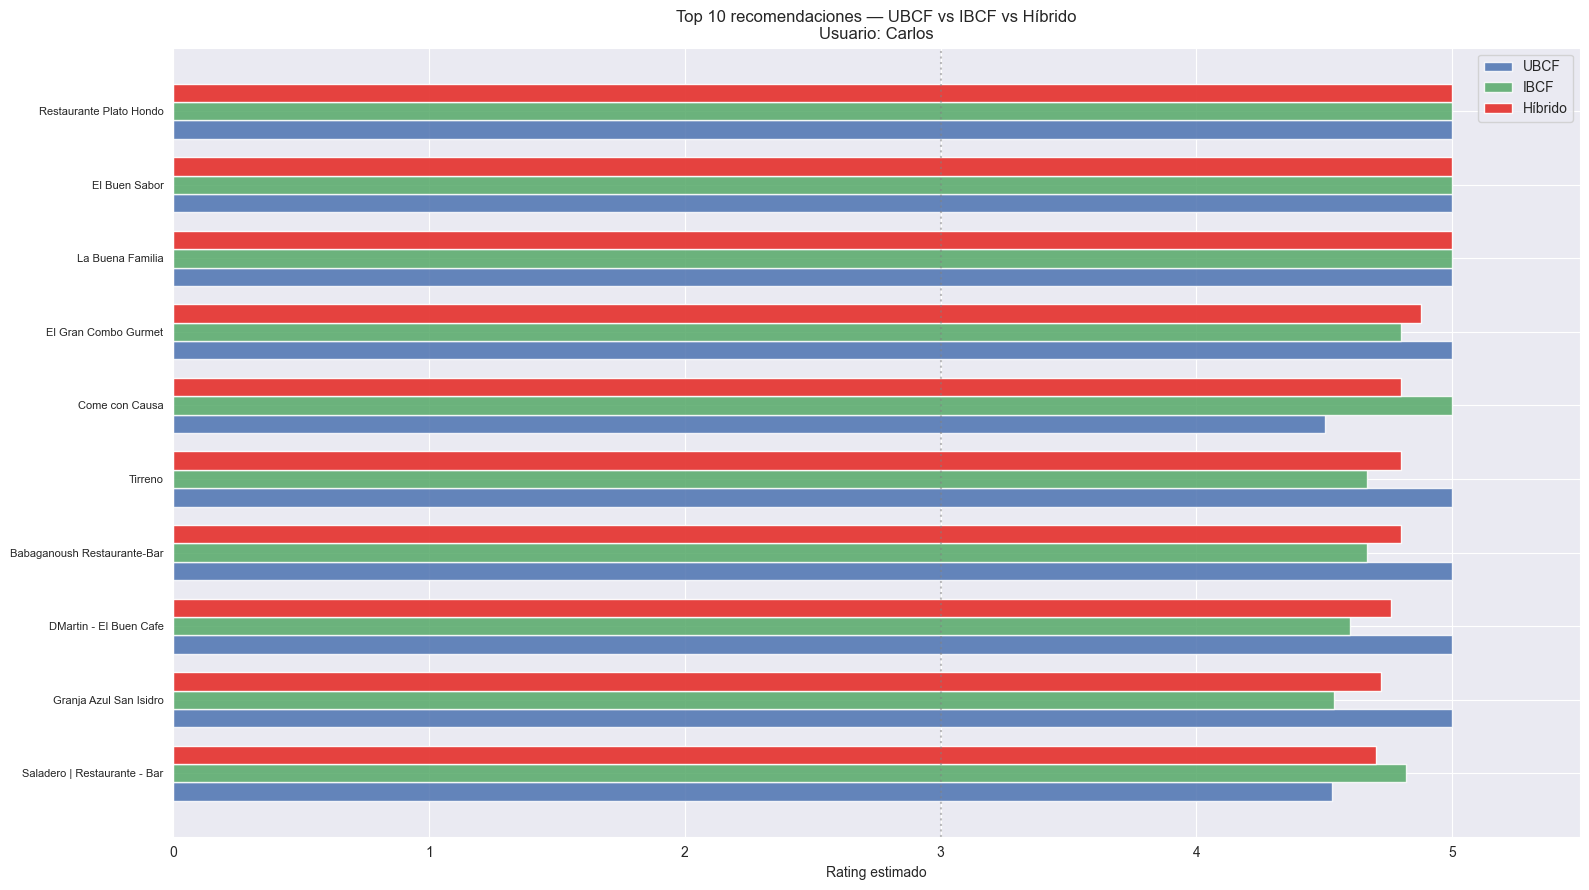

In [26]:
# ── Visualización top-10 híbrido ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))

nombres = [t[:30]+'…' if len(t)>30 else t for t in top10_u1['Restaurante']]
x = np.arange(len(nombres))
w = 0.25

ax.barh(x + w,   top10_u1['Rating UBCF'],   w, label='UBCF',   color='#4C72B0', alpha=0.85)
ax.barh(x,       top10_u1['Rating IBCF'],   w, label='IBCF',   color='#55A868', alpha=0.85)
ax.barh(x - w,   top10_u1['Rating Híbrido'],w, label='Híbrido', color='#e53935', alpha=0.95)

ax.set_yticks(x)
ax.set_yticklabels(nombres, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Rating estimado')
ax.set_title(f'Top 10 recomendaciones — UBCF vs IBCF vs Híbrido\nUsuario: {usuario_1[:40]}')
ax.axvline(x=3, color='gray', linestyle=':', alpha=0.5)
ax.legend()
ax.set_xlim(0, 5.5)
plt.tight_layout()
plt.show()

## 5. Resumen y Conclusiones

### Resultados de modelos

| Modelo | RMSE | MAE | Observación |
|---|---|---|---|
| UBCF coseno | 0.9919 | 0.7674 | Mayor error — afectado por dispersidad |
| IBCF coseno | 0.9356 | 0.6473 | Mejor MAE individual |
| **Híbrido (0.4×UBCF + 0.6×IBCF)** | **0.9053** | **0.6669** | **Mejor RMSE — modelo seleccionado** |

### ¿Por qué el híbrido supera a ambos modelos individuales?

El modelo UBCF captura preferencias personales del usuario (a quién se parece),
mientras que IBCF captura la estructura del ítem (qué restaurantes se parecen).
Al combinarlos con los pesos óptimos encontrados por grid search,
el híbrido aprovecha ambas señales reduciendo el error global en **RMSE**.

### Criterios del sistema
- **Filtrado:** Usuarios ≥ 10 reseñas · Restaurantes ≥ 20 reseñas
- **Similitud:** Coseno en ambos modelos base
- **Combinación:** `0.4 × UBCF + 0.6 × IBCF` (óptimo por grid search)
- **Salida:** Top-N restaurantes no visitados con mayor rating híbrido estimado